In [3]:
from scipy.ndimage import correlate
import numpy as np

In [17]:
input_img = np.arange(25).reshape(5, 5)
print(input_img)
weights = [[0, 1, 0],
		   [1, 2, 1],
		   [0, 1, 0]]
res_img_reflect = correlate(input_img, weights, mode="reflect")
res_img_cst = correlate(input_img, weights, mode="constant", cval=10)
print(res_img_cst - res_img_reflect)


[[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]
 [15 16 17 18 19]
 [20 21 22 23 24]]
[[ 20   9   8   7  12]
 [  5   0   0   0   1]
 [  0   0   0   0  -4]
 [ -5   0   0   0  -9]
 [-20 -11 -12 -13 -28]]


<class 'numpy.ndarray'>
(450, 450)


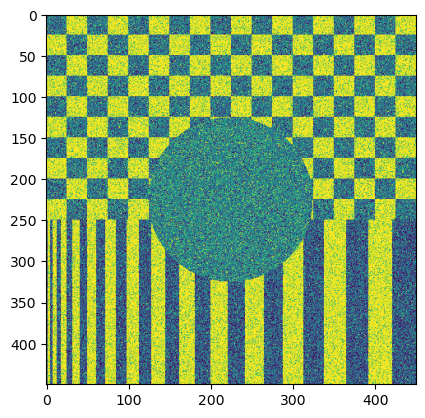

In [22]:
from skimage import io
import matplotlib.pyplot as plt

# Load an image (RGB or grayscale depending on the file)
img = io.imread("../data/Gaussian.png", as_gray=True)

print(type(img))   # numpy.ndarray
print(img.shape)   # (H, W, 3) for color, (H, W) for grayscale
plt.imshow(img)

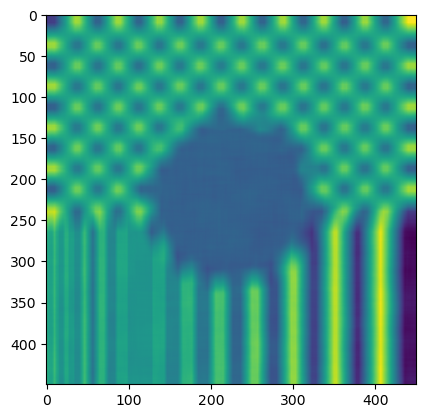

In [25]:
size = 30
# Two dimensional filter filled with 1
weights = np.ones([size, size])
# Normalize weights
weights = weights / np.sum(weights)
correlated_img = correlate(img, weights)
plt.imshow(correlated_img)

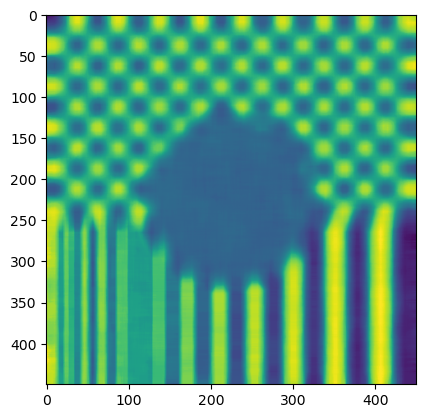

In [29]:
from skimage.filters import median
size = 30
footprint = np.ones([size, size])
med_img = median(img, footprint)
plt.imshow(med_img)

(450, 450)


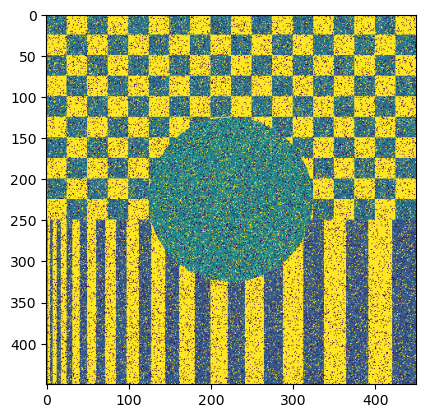

In [35]:
salt_pepper_img = io.imread("../data/SaltPepper.png", as_gray=True)
print(salt_pepper_img.shape)
plt.imshow(salt_pepper_img)

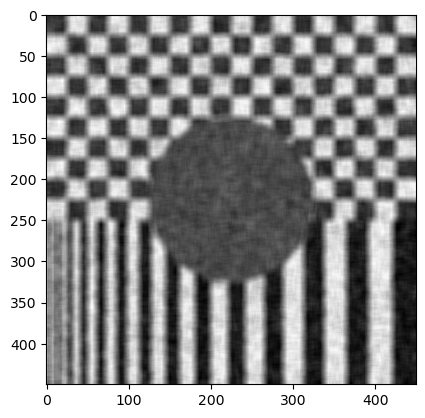

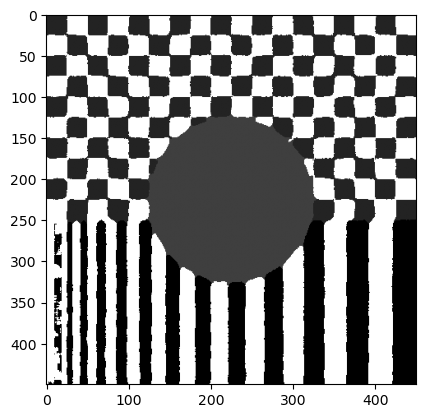

In [38]:
size = 10
# Two dimensional filter filled with 1
weights = np.ones([size, size])
# Normalize weights
weights = weights / np.sum(weights)
mean_salt = correlate(salt_pepper_img, weights)
plt.imshow(mean_salt, cmap="gray")
plt.show()
footprint = np.ones([size, size])
med_salt = median(salt_pepper_img, footprint)
plt.imshow(med_salt, cmap="gray")
plt.show()


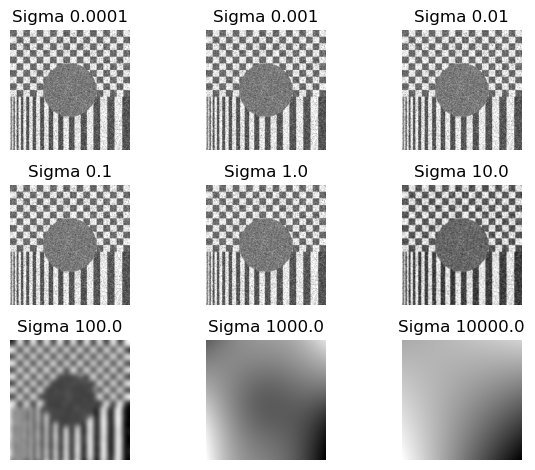

In [44]:
from skimage.filters import gaussian
sigma = 1e-5
fig, ax = plt.subplots(3,3)
ax = ax.ravel()
for i in range(9):
    gauss_img = gaussian(salt_pepper_img, sigma)
    ax[i].imshow(gauss_img, cmap="gray")
    sigma *= 10
    ax[i].axis("off")
    ax[i].set_title(f"Sigma {sigma}")
plt.tight_layout()

In [45]:
from skimage.filters import prewitt_h
from skimage.filters import prewitt_v
from skimage.filters import prewitt

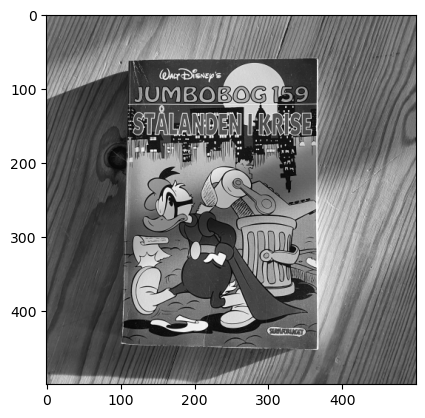

In [46]:
donald_img = io.imread("../data/donald_1.png", as_gray=True)
plt.imshow(donald_img, cmap="gray")

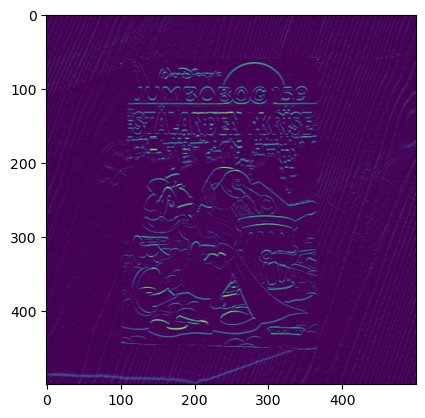

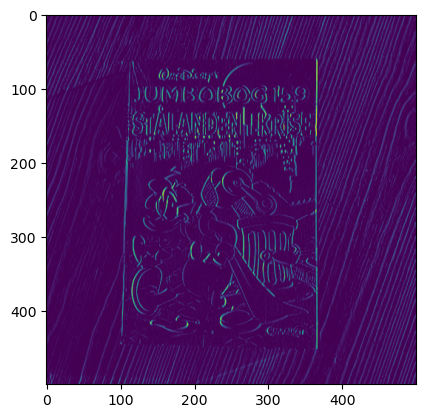

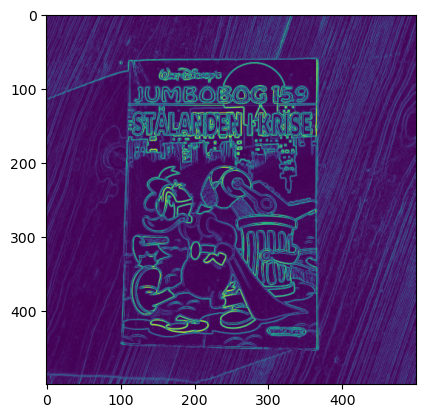

In [52]:
from skimage import io, img_as_ubyte, img_as_float
prewitt_h_img = img_as_ubyte(prewitt_h(donald_img))
plt.imshow(prewitt_h_img)
plt.show()
prewitt_v_img = img_as_ubyte(prewitt_v(donald_img))
plt.imshow(prewitt_v_img)
plt.show()
prewitt_img = img_as_ubyte(prewitt(donald_img))
plt.imshow(prewitt_img)
plt.show()

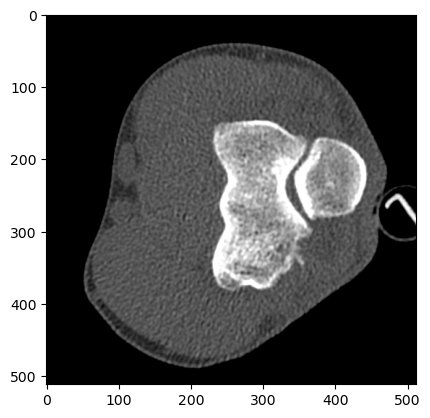

In [60]:
elbow_img = io.imread("../data/ElbowCTSlice.png", as_gray=True)
plt.imshow(elbow_img, cmap="gray")

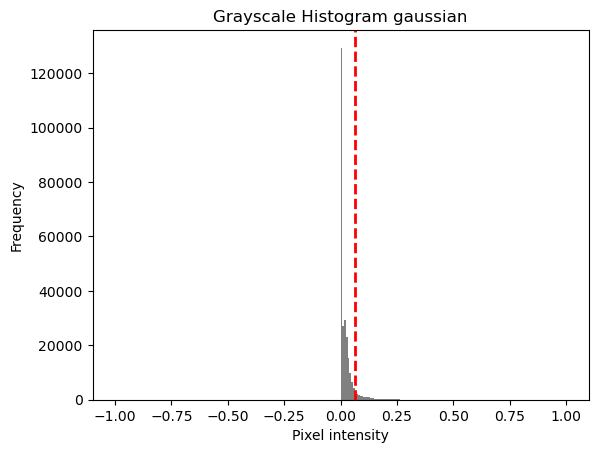

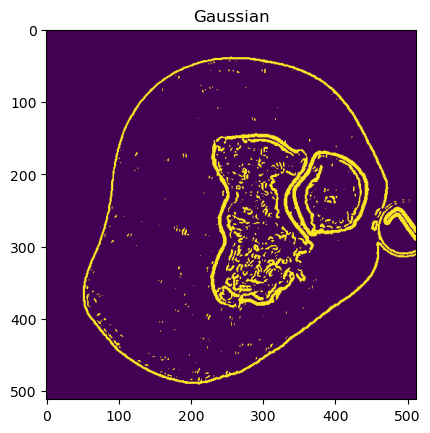

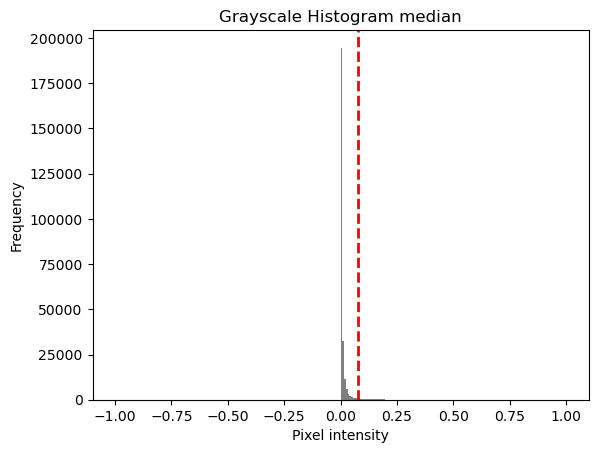

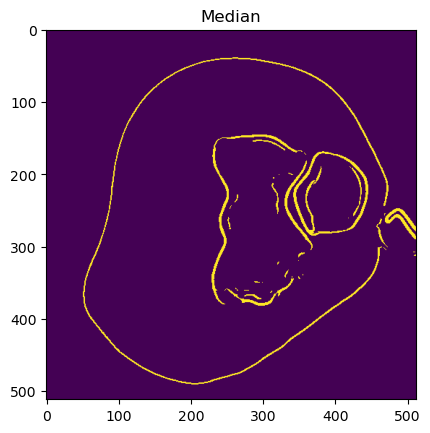

In [74]:
from skimage.filters import threshold_otsu
def get_edges(img, filter="gaussian"):
    if filter == "gaussian":
        filtered_img = gaussian(elbow_img, sigma=1)
    elif filter == "median":
        size = 10
        footprint = np.ones([size, size])
        filtered_img = median(elbow_img, footprint)
    prewitt_elbow = prewitt(filtered_img)
    T = threshold_otsu(prewitt_elbow)
    binary_img = prewitt_elbow > T
    plt.hist(prewitt_elbow.ravel(), bins=256, range=(-1, 1), color='gray')  # 0–1 since skimage loads floats
    plt.title(f"Grayscale Histogram {filter}")
    plt.xlabel("Pixel intensity")
    plt.ylabel("Frequency")
    plt.axvline(x=T, color='red', linestyle='--', linewidth=2, label="Threshold 0.5")
    plt.show()
    return binary_img

plt.imshow(get_edges(elbow_img, filter="gaussian"))
plt.title("Gaussian")
plt.show()
plt.imshow(get_edges(elbow_img, filter="median"))
plt.title("Median")
plt.show()